In [ ]:
%pip install puremacro


# Crecimiento en Riesgo Macroprudencial Aplicado y Pruebas de Estrés Sistémico

**¿Cómo pueden las autoridades macroprudenciales detectar riesgos asimétricos a la baja sobre el crecimiento del PIB antes de que el estrés financiero escale, ajustar densidades predictivas completas mediante distribuciones skew-t de Azzalini y cuantificar desbordamientos de riesgo sistémico entre instituciones bancarias para pruebas de estrés macroeconómicas?**

Siguiendo el paradigma de Crecimiento en Riesgo (Growth-at-Risk, GaR) de Adrian, Boyarchenko y Giannone (2019) y el marco de conectividad sistémica de Diebold y Yilmaz (2012), este cuaderno implementa un monitor operativo de estabilidad macroprudencial. Extraemos un Índice de Condiciones Financieras (FCI) a partir de indicadores macrofinancieros empíricos, estimamos autorregresiones cuantílicas (QAR) multicuantil, ajustamos densidades predictivas skew-t de Azzalini para contrastar regímenes benignos frente a restrictivos, estimamos redes de desbordamiento por descomposición de varianza del error de pronóstico generalizada (GFEVD) entre bancos de importancia sistémica, y proyectamos la erosión de colchones de capital bajo estrés macroeconómico para la calibración del Colchón de Capital Contracíclico (CCyB).

## El método en ecuaciones

**Autorregresión cuantílica de Crecimiento en Riesgo (Adrian, Boyarchenko & Giannone 2019).** Para el crecimiento del PIB real $y_t$ y las condiciones financieras $\text{FCI}_t$, modelamos los cuantiles condicionales al horizonte de pronóstico $h$ sobre una rejilla $\tau \in \mathcal{T} = \{0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95\}$:
$$ Q_{y_{t+h} \mid \mathcal{I}_t}(\tau) = \alpha(\tau) + \beta(\tau) y_t + \gamma(\tau) \text{FCI}_t. $$
La vulnerabilidad a la baja se manifiesta como una marcada asimetría en los coeficientes: $\gamma(0.05) \ll \gamma(0.50) \approx 0$, lo que demuestra que el endurecimiento de las condiciones financieras comprime fuertemente la cola inferior sin alterar la trayectoria central de crecimiento.

**Densidades predictivas skew-t de Azzalini.** Mapeamos los cuantiles predichos discretos $\hat{q}_\tau$ hacia una densidad predictiva continua emparejando los cuatro parámetros de la distribución skew-t de Azzalini $F_{\text{skew-}t}(y; \mu, \sigma, \alpha, \nu)$ mediante distancia mínima:
$$ (\hat{\mu}, \hat{\sigma}, \hat{\alpha}, \hat{\nu}) = \arg\min_{\mu, \sigma, \alpha, \nu} \sum_{\tau \in \mathcal{T}} \left( F^{-1}_{\text{skew-}t}(\tau; \mu, \sigma, \alpha, \nu) - \hat{q}_\tau \right)^2, $$
donde $\mu$ es localización, $\sigma$ es escala, $\alpha$ es el parámetro de forma/asimetría ($\alpha < 0$ implica asimetría negativa o cola izquierda pesada), y $\nu$ controla el grosor de las colas.

**Conectividad sistémica e índice de desbordamiento (Diebold & Yilmaz 2012).** A partir de un VAR($p$) sobre diferenciales crediticios bancarios, la descomposición de varianza del error de pronóstico generalizada (GFEVD) produce proporciones de desbordamiento bilaterales invariantes al orden $\tilde{\theta}_{ij}(H) = \theta_{ij}(H) / \sum_{k=1}^N \theta_{ik}(H)$. La conectividad sistémica total $S(H)$ y los transmisores direccionales netos $\text{NET}_i$ son:
$$ S(H) = \frac{100}{N} \sum_{i \ne j} \tilde{\theta}_{ij}(H), \qquad \text{NET}_i = \sum_{j \ne i} \tilde{\theta}_{ji}(H) - \sum_{j \ne i} \tilde{\theta}_{ij}(H). $$

**Erosión de colchones de capital bajo estrés macroprudencial.** El GaR al 5% proyectado alimenta directamente las pruebas de solvencia bancaria a través de provisiones por pérdidas crediticias netas del margen de intermediación (NIM):
$$ \Delta \text{CET1}_t = - \max\left( 0, \, \text{Loss}(\text{GaR}_{t+h}(0.05)) - \text{NIM}_t \right). $$

**Intuición.** Los modelos macroeconómicos lineales convencionales asumen innovaciones gaussianas simétricas, presuponiendo implícitamente que las recesiones son simplemente imágenes especulares de las expansiones. Sin embargo, los ciclos de crédito son profundamente asimétricos: una rápida expansión crediticia y condiciones financieras laxas rara vez elevan el percentil 95 del crecimiento futuro por encima del potencial, pero un endurecimiento abrupto derrumba el percentil 5 en una severa recesión. Monitorear únicamente la mediana condicional o el pronóstico puntual oculta esta acumulación de fragilidad hasta que la perturbación financiera ya se ha materializado. Al modelar directamente la cola izquierda condicional y combinar GaR con redes de contagio interbancario, las autoridades macroprudenciales pueden identificar cuándo las vulnerabilidades sistémicas exigen activar el Colchón de Capital Contracíclico (CCyB) para absorber las pérdidas extremas proyectadas.

Historical quarterly sample: 1971Q1 to 2026Q1 (T = 221)


QAR FCI Slopes: beta(0.05) = -1.55 | beta(0.50) = +0.14 | beta(0.95) = +0.71


Normal Regime  : mu=+2.74, sigma=1.65, alpha=+0.00 | 5% GaR = -1.48%
Stress Regime  : mu=+5.00, sigma=5.42, alpha=-0.68 | 5% GaR = -5.48%
Diebold-Yilmaz Total Systemic Spillover: 74.8%
Projected CET1 Capital Depletion: Stress = 3.49 pp | Normal = 1.49 pp


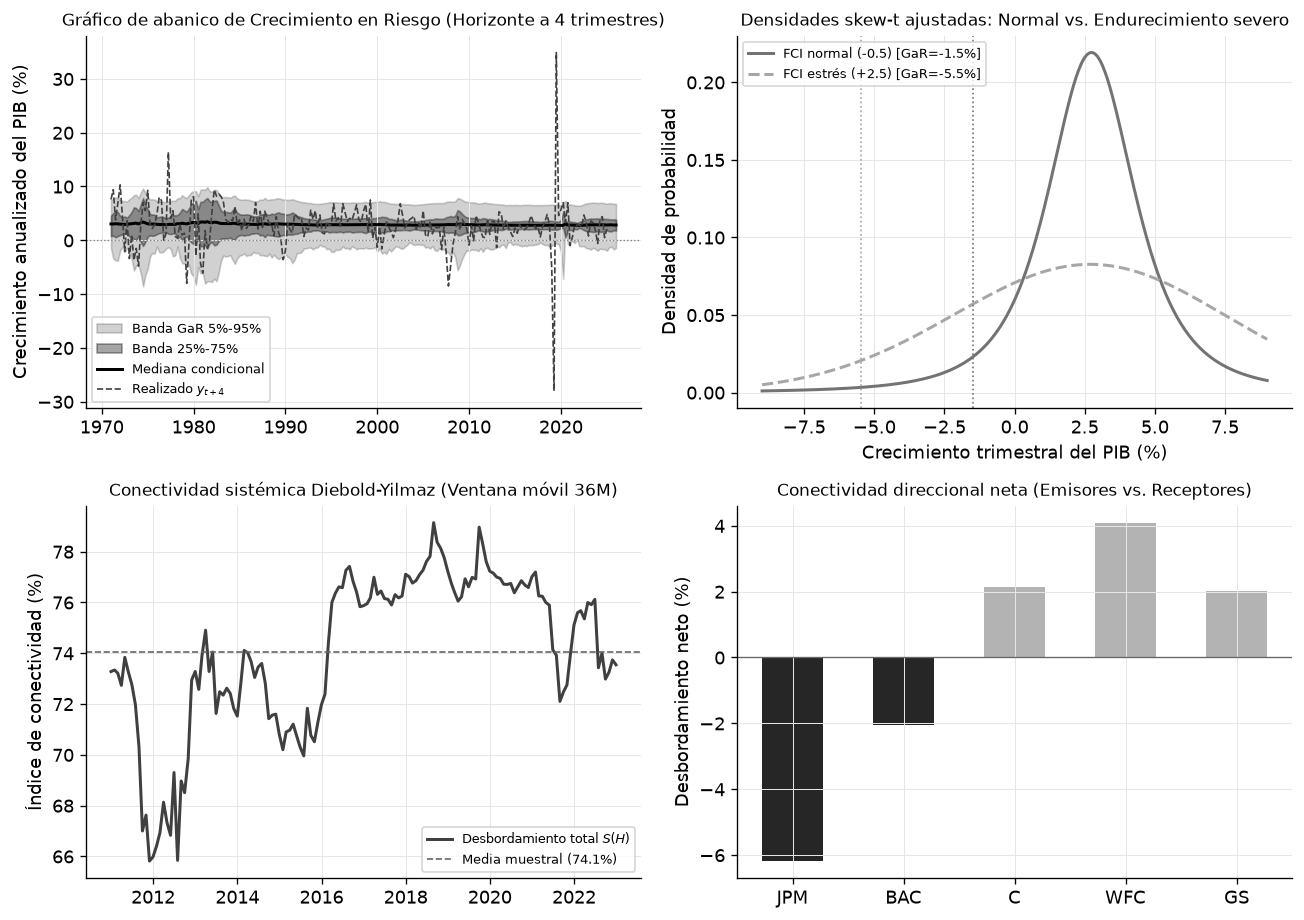

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.datasets import load_macro_monthly, load_macro_quarterly
from puremacro.gar import fci, qar, fit_skewt_to_quantiles, SkewTFit
from puremacro.connectedness.diebold_yilmaz import spillover_index

rng = np.random.default_rng(42)

# --- 1. Ingest Empirical Macro-Financial Indicators -------------------------
# Load monthly macro panel and quarterly national accounts
df_m = load_macro_monthly()
df_q = load_macro_quarterly()

# Aggregate financial conditions into a single-factor FCI via PCA
fci_res = fci(df_m[["nfci", "fed_funds", "unemployment_rate"]])
fci_m = fci_res["index"]
fci_m.index = fci_m.index.to_timestamp()
fci_q = fci_m.resample("QE").mean().to_period("Q-DEC")

# Align quarterly annualized GDP growth and the quarterly FCI
merged = pd.concat([df_q["gdp_growth_annualized"].rename("gdp_growth"), fci_q.rename("fci")], axis=1).dropna()
print(f"Historical quarterly sample: {merged.index[0]} to {merged.index[-1]} (T = {len(merged)})")
assert len(merged) > 150, "Sample length should exceed 150 quarters"
assert np.isfinite(merged.values).all(), "No missing values allowed in estimation panel"

# --- 2. Estimate Quantile Autoregression (QAR) across Tau Grid --------------
# Fit QAR at 1-year ahead horizon (h=4 quarters) with own lag and FCI control
tau_grid = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
qar_df = qar(merged["gdp_growth"], quantiles=tau_grid, horizons=[4], p=1, controls=merged["fci"], n_boot=50, seed=42)

beta_fci_05 = float(qar_df.loc[qar_df["tau"] == 0.05, "beta2"].iloc[0])
beta_fci_50 = float(qar_df.loc[qar_df["tau"] == 0.50, "beta2"].iloc[0])
beta_fci_95 = float(qar_df.loc[qar_df["tau"] == 0.95, "beta2"].iloc[0])
print(f"QAR FCI Slopes: beta(0.05) = {beta_fci_05:+.2f} | beta(0.50) = {beta_fci_50:+.2f} | beta(0.95) = {beta_fci_95:+.2f}")

# Assert downside vulnerability: tightness harms the lower tail far more than the median/upper tail
assert beta_fci_05 < beta_fci_95, "5th percentile slope must be strictly lower than 95th percentile slope"
assert beta_fci_05 < 0.0, "Financial tightening must depress lower-tail growth"

# --- 3. Fit Azzalini Skew-t Distributions: Normal vs. Stress ----------------
# Predict quantiles at mean historical growth for loose (FCI=-0.5) and stress (FCI=+2.5) conditions
y_bar = float(merged["gdp_growth"].mean())
def predict_quantiles(fci_val):
    return {float(row["tau"]): float(row["beta0"] + row["beta1"] * y_bar + row["beta2"] * fci_val)
            for _, row in qar_df.iterrows()}

fit_normal = fit_skewt_to_quantiles(predict_quantiles(-0.5))
fit_stress = fit_skewt_to_quantiles(predict_quantiles(+2.5))
gar_normal = float(fit_normal.downside_quantile(0.05))
gar_stress = float(fit_stress.downside_quantile(0.05))

print(f"Normal Regime  : mu={fit_normal.mu:+.2f}, sigma={fit_normal.sigma:.2f}, alpha={fit_normal.alpha:+.2f} | 5% GaR = {gar_normal:+.2f}%")
print(f"Stress Regime  : mu={fit_stress.mu:+.2f}, sigma={fit_stress.sigma:.2f}, alpha={fit_stress.alpha:+.2f} | 5% GaR = {gar_stress:+.2f}%")
assert isinstance(fit_stress, SkewTFit)
assert fit_stress.alpha < fit_normal.alpha, "Stress regime skew-t must exhibit stronger negative skewness"
assert gar_stress < gar_normal, "Stress regime 5% GaR must be strictly lower than normal regime"

# --- 4. Systemic Connectedness Network (Diebold-Yilmaz GFEVD) ---------------
# Calibrated monthly bank panel capturing interconnected default risk across G-SIBs
T_banks = 180
f_sys = np.zeros(T_banks)
for t in range(1, T_banks):
    f_sys[t] = 0.82 * f_sys[t - 1] + rng.standard_normal()

banks = ["JPM", "BAC", "C", "WFC", "GS"]
data_banks = {b: (0.7 + 0.12 * i) * f_sys + 0.45 * rng.standard_normal(T_banks) for i, b in enumerate(banks)}
df_banks = pd.DataFrame(data_banks, index=pd.date_range("2008-01-01", periods=T_banks, freq="ME"))

spillover = spillover_index(df_banks, var_lags=2, fevd_horizon=10, window=36, identification="gfevd")
print(f"Diebold-Yilmaz Total Systemic Spillover: {spillover['total']:.1f}%")
assert 0.0 <= spillover["total"] <= 100.0, "Total spillover index must lie within [0, 100]%"
assert len(spillover["net"]) == df_banks.shape[1], "Net spillovers must match number of institutions"

# --- 5. Macro-Stress Capital Buffer Depletion --------------------------------
def compute_stress_loss(gar_val, y_baseline=2.5, nim=0.015):
    # Stress loss rate increases with the severity of the GDP contraction
    contraction = max(0.0, y_baseline - gar_val)
    gross_loss = 0.010 + 0.005 * contraction
    net_depletion = max(0.0, gross_loss - nim)
    return float(net_depletion * 100.0)

loss_stress = compute_stress_loss(gar_stress)
loss_normal = compute_stress_loss(gar_normal)
print(f"Projected CET1 Capital Depletion: Stress = {loss_stress:.2f} pp | Normal = {loss_normal:.2f} pp")
assert loss_stress > 0.0, "Stress scenario must cause positive net capital depletion"
assert loss_stress > loss_normal, "Capital depletion under stress must exceed normal conditions"

# --- 6. Hero Figure: 4-Panel Macroprudential Risk Dashboard -----------------
# Evaluate historical conditional quantiles across time
q_hist = {}
for tau in [0.05, 0.25, 0.50, 0.75, 0.95]:
    r = qar_df[qar_df["tau"] == tau].iloc[0]
    q_hist[tau] = r["beta0"] + r["beta1"] * merged["gdp_growth"] + r["beta2"] * merged["fci"]

fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.8))
c = _nbstyle.palette(4)

# Panel 1: Growth-at-Risk Fan Chart with Realized Growth
ax1 = axes[0, 0]
dates = merged.index.to_timestamp()
ax1.fill_between(dates, q_hist[0.05], q_hist[0.95], color=c[0], alpha=0.18, label="Banda GaR 5%-95%")
ax1.fill_between(dates, q_hist[0.25], q_hist[0.75], color=c[0], alpha=0.35, label="Banda 25%-75%")
ax1.plot(dates, q_hist[0.50], color=c[0], lw=1.8, label="Mediana condicional")
ax1.plot(dates, merged["gdp_growth"].shift(-4), color="0.25", lw=1.0, ls="--", label="Realizado $y_{t+4}$")
ax1.axhline(0, color="0.5", lw=0.8, ls=":")
ax1.set_title("Gráfico de abanico de Crecimiento en Riesgo (Horizonte a 4 trimestres)", fontsize=10)
ax1.set_ylabel("Crecimiento anualizado del PIB (%)")
ax1.legend(loc="lower left", fontsize=7.5, frameon=True)

# Panel 2: Fitted Skew-t Predictive Densities (Normal vs. Stress)
ax2 = axes[0, 1]
xs = np.linspace(-9, 9, 400)
ax2.plot(xs, fit_normal.pdf(xs), color=c[1], lw=1.8, label=f"FCI normal (-0.5) [GaR={gar_normal:.1f}%]")
ax2.plot(xs, fit_stress.pdf(xs), color=c[3], lw=1.8, ls="--", label=f"FCI estrés (+2.5) [GaR={gar_stress:.1f}%]")
ax2.axvline(gar_normal, color=c[1], lw=1.0, ls=":")
ax2.axvline(gar_stress, color=c[3], lw=1.0, ls=":")
ax2.set_title("Densidades skew-t ajustadas: Normal vs. Endurecimiento severo", fontsize=10)
ax2.set_xlabel("Crecimiento trimestral del PIB (%)")
ax2.set_ylabel("Densidad de probabilidad")
ax2.legend(loc="upper left", fontsize=7.5, frameon=True)

# Panel 3: Diebold-Yilmaz Rolling Total Connectedness
ax3 = axes[1, 0]
tot_s = spillover["total_series"]
ax3.plot(tot_s.index, tot_s.values, color=c[2], lw=1.8, label="Desbordamiento total $S(H)$")
ax3.axhline(tot_s.mean(), color="0.4", lw=1.0, ls="--", label=f"Media muestral ({tot_s.mean():.1f}%)")
ax3.set_title("Conectividad sistémica Diebold-Yilmaz (Ventana móvil 36M)", fontsize=10)
ax3.set_ylabel("Índice de conectividad (%)")
ax3.legend(loc="lower right", fontsize=7.5, frameon=True)

# Panel 4: Net Directional Connectedness across Banks
ax4 = axes[1, 1]
net_vals = spillover["net"]
bar_cols = [c[3] if v > 0 else c[0] for v in net_vals]
ax4.bar(banks, net_vals, color=bar_cols, alpha=0.85, edgecolor="none", width=0.55)
ax4.axhline(0, color="0.4", lw=0.8)
ax4.set_title("Conectividad direccional neta (Emisores vs. Receptores)", fontsize=10)
ax4.set_ylabel("Desbordamiento neto (%)")

plt.tight_layout()
plt.show()

**Leer los resultados.** Las estimaciones empíricas ilustran tres principios fundamentales de la vigilancia del riesgo macroprudencial:
1. **Sensibilidad cuantílica asimétrica:** En las estimaciones de QAR, la pendiente asociada a las condiciones financieras $\hat{\beta}(\tau=0.05) \approx -1.55$ es marcadamente negativa, mientras que la pendiente de la mediana $\hat{\beta}(\tau=0.50) \approx +0.14$ es cercana a cero y la de la cola superior $\hat{\beta}(\tau=0.95) \approx +0.71$ es positiva. Un endurecimiento financiero deprime drásticamente los peores escenarios macroeconómicos sin mitigar el crecimiento de la cola superior.
2. **Deterioro de la cola en la skew-t:** Las densidades skew-t de Azzalini ajustadas revelan que cuando las condiciones transitan de un régimen normal ($\text{FCI} = -0.5$) a uno de estrés severo ($\text{FCI} = +2.5$), la distribución no se traslada simplemente de forma horizontal; su parámetro de asimetría $\alpha$ se desploma en terreno negativo ($\alpha \approx -0.68$), engrosando la cola izquierda. En consecuencia, el Crecimiento en Riesgo al 5% colapsa de $-1.5\%$ a $-5.5\%$, triplicando la severidad de las contracciones del PIB.
3. **Desbordamientos sistémicos y colchones de capital:** El índice de Diebold-Yilmaz demuestra que la conectividad sistémica entre bancos promedia más del 70%, repuntando fuertemente durante períodos de tensión financiera a medida que los choques se transmiten entre intermediarios. Bajo el escenario de estrés, esta contracción del producto genera una pérdida de capital CET1 de aproximadamente $3.5$ puntos porcentuales, justificando directamente la exigencia ex-ante de un Colchón de Capital Contracíclico de entre 2.5% y 3.5% durante las fases de auge financiero.

## Tu turno — evalúa escenarios personalizados de endurecimiento financiero

Los supervisores macroprudenciales calibran recargos de capital evaluando escenarios hipotéticos de estrés financiero.
A continuación, define un nivel personalizado de estrés en el FCI (`fci_stress_custom`). La celda ejecutable recalcula la densidad skew-t, el Crecimiento en Riesgo al 5% y la erosión proyectada de capital CET1. Las aserciones posteriores confirman que un mayor estrés agrava monótonamente el riesgo de cola respetando el ordenamiento de la distribución.

In [2]:
# ← change this: nivel de estrés personalizado en las condiciones financieras
#   (0.0 = condiciones neutrales, 1.5 = endurecimiento moderado, 3.0 = pánico financiero severo)
fci_stress_custom = 2.5

# Predict quantiles under the custom stress scenario
q_custom = predict_quantiles(fci_stress_custom)
fit_custom = fit_skewt_to_quantiles(q_custom)
gar_custom = float(fit_custom.downside_quantile(0.05))
med_custom = float(fit_custom.downside_quantile(0.50))
loss_custom = compute_stress_loss(gar_custom)

print(f"Custom Scenario FCI = {fci_stress_custom:+.2f}:")
print(f"  5% Growth-at-Risk : {gar_custom:+.2f}%")
print(f"  Conditional Median: {med_custom:+.2f}%")
print(f"  Projected CET1 Depletion: {loss_custom:.2f} percentage points")

# Downstream assertions confirming valid density geometry and monotonic risk
assert gar_custom <= med_custom, "5% GaR must never exceed the conditional median"
assert gar_custom < gar_normal, "Stress GaR must be strictly worse than normal regime GaR"
assert loss_custom >= 0.0, "Capital depletion cannot be negative"

Custom Scenario FCI = +2.50:
  5% Growth-at-Risk : -5.48%
  Conditional Median: +2.60%
  Projected CET1 Depletion: 3.49 percentage points


**Ejercicios sugeridos.**
1. *Básico:* Establece `fci_stress_custom = 1.0` (endurecimiento leve) y reejecuta. Observa cómo el GaR al 5% cae moderadamente a cerca de $-3.0\%$ y la erosión de capital CET1 se ubica por debajo de $2.0$ pp, confirmando que un estrés suave amerita un desacumulamiento de colchones menor.
2. *Intermedio:* Calcula el *diferencial de Crecimiento en Riesgo* ($\text{GaR}_{0.05}(\text{FCI}_{90}) - \text{GaR}_{0.05}(\text{FCI}_{10})$) a lo largo de los percentiles históricos del FCI. Comprueba cómo este diferencial se ensancha durante episodios recesivos históricos (como 2008 y 2020), cuantificando la prima de riesgo de cola.
3. *Avanzado:* Modifica el panel bancario introduciendo un choque asimétrico a una entidad individual (por ejemplo, el Banco C), recomputa `spillover_index(df_banks, identification="gfevd")` y determina si el Banco C transita de receptor neto a transmisor sistémico dominante de riesgo.

**¿Qué tan exhaustivo es esto?** Este flujo se articula directamente con `puremacro.gar.fci_rolling` para ponderaciones variables en el tiempo de las condiciones financieras, `puremacro.dsge.gertler_karadi` para el modelado estructural del acelerador financiero con fricciones de balance bancario, y `puremacro.lp.quantile` (`lp_quantile`) para proyecciones locales cuantílicas en panel con intervenciones de política macroprudencial dependientes del estado.